In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [46]:
df = pd.read_csv("C:/Users/admin/Downloads/machine-learning-code-orbit/from_tufool/Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [47]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

Shape: (10000, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB
None


In [48]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [49]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          71.000

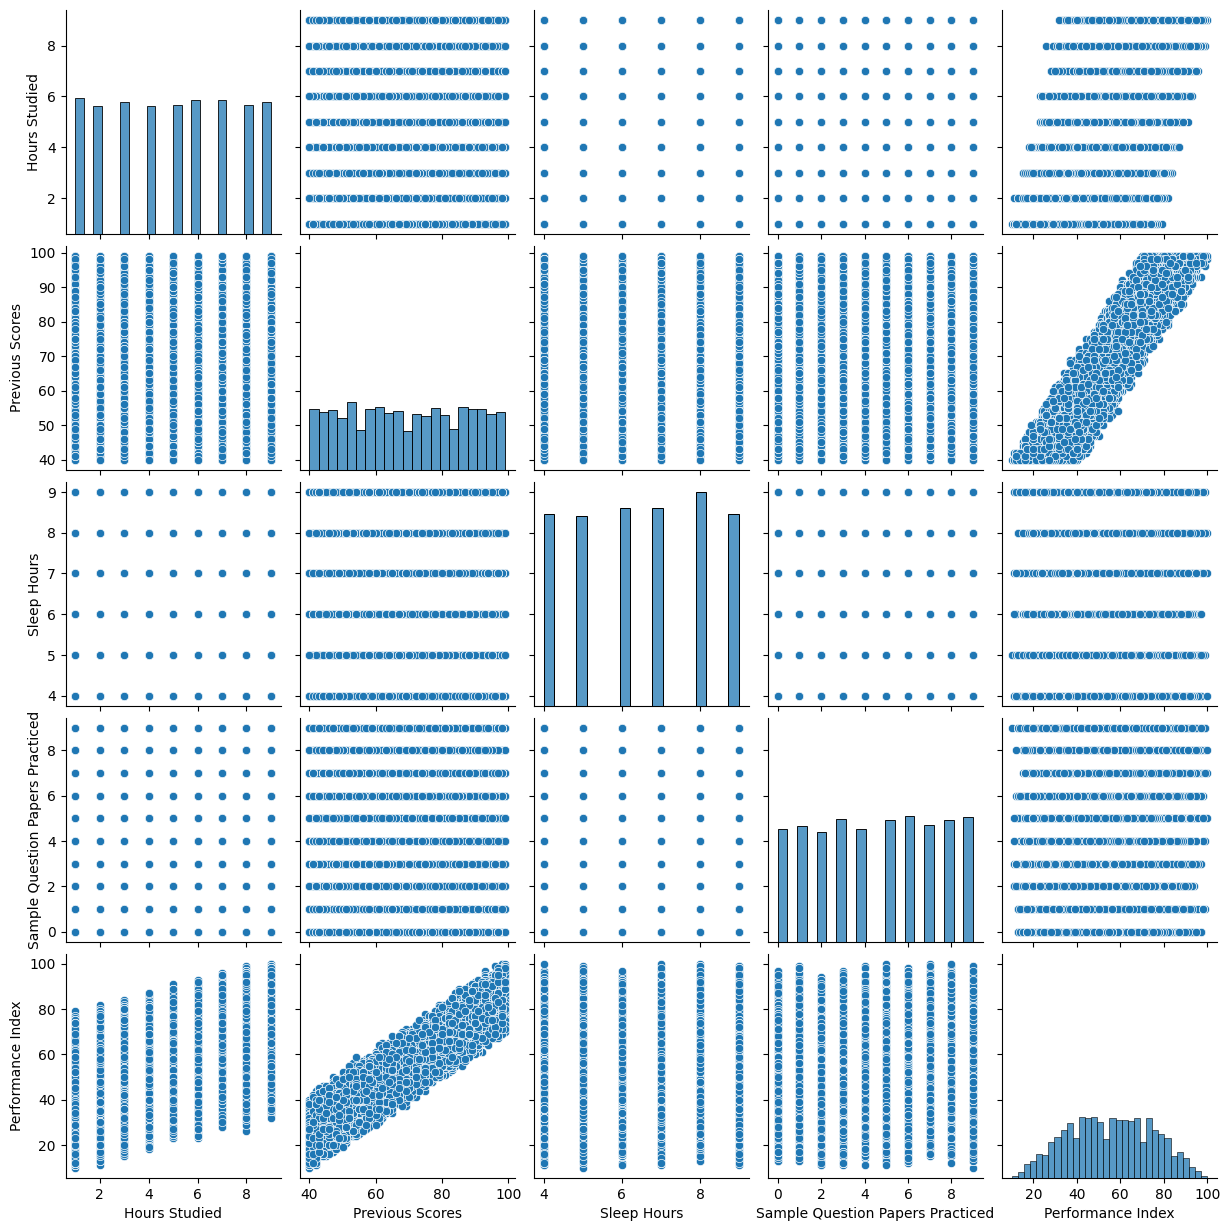

In [50]:
sns.pairplot(df)
plt.show()

In [51]:
df.dropna(inplace=True)

In [52]:
print("Columns:", df.columns)

Columns: Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')


In [53]:
target_col = 'Performance Index'

In [54]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_encoded = pd.get_dummies(X, drop_first=True)

print("Any non-numeric columns?", X_encoded.select_dtypes(include='object').columns.tolist())

Any non-numeric columns? []


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
print(X_encoded.dtypes)

Hours Studied                       int64
Previous Scores                     int64
Sleep Hours                         int64
Sample Question Papers Practiced    int64
Extracurricular Activities_Yes       bool
dtype: object


#### MODEL EVALUATION FUNCTION

In [58]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Evaluation:")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

#### LINEAR REGRESSION

In [59]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
evaluate_model("Linear Regression", y_test, lr_pred)


Linear Regression Evaluation:
R2 Score: 0.9889832909573145
MAE: 1.6111213463123026
MSE: 4.082628398521843
RMSE: 2.0205515085050028


#### POLYNOMIAL REGRESSION

In [60]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_scaled)
X_poly_test = poly.transform(X_test_scaled)

In [61]:
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
poly_pred = poly_model.predict(X_poly_test)
evaluate_model("Polynomial Regression", y_test, poly_pred)


Polynomial Regression Evaluation:
R2 Score: 0.9889886481405484
MAE: 1.6115229438315108
MSE: 4.08064310615166
RMSE: 2.020060173893753


#### LASSO REGRESSION

In [62]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
evaluate_model("Lasso Regression", y_test, lasso_pred)


Lasso Regression Evaluation:
R2 Score: 0.9887332299501382
MAE: 1.6267286591738161
MSE: 4.175297285873364
RMSE: 2.0433544200342153


#### RIDGE REGRESSION

In [63]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
evaluate_model("Ridge Regression", y_test, ridge_pred)


Ridge Regression Evaluation:
R2 Score: 0.9889817176387807
MAE: 1.6112232352490106
MSE: 4.083211446953203
RMSE: 2.020695782881036


#### DECISION TREE REGRESSOR

In [64]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
evaluate_model("Decision Tree Regressor", y_test, tree_pred)



Decision Tree Regressor Evaluation:
R2 Score: 0.9762144536737292
MAE: 2.3390833333333334
MSE: 8.814569444444444
RMSE: 2.9689340586217883


#### RANDOM FOREST REGRESSOR

In [65]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
evaluate_model("Random Forest Regressor", y_test, rf_pred)


Random Forest Regressor Evaluation:
R2 Score: 0.9860794546822804
MAE: 1.814741986111111
MSE: 5.15874690135038
RMSE: 2.271287498611829


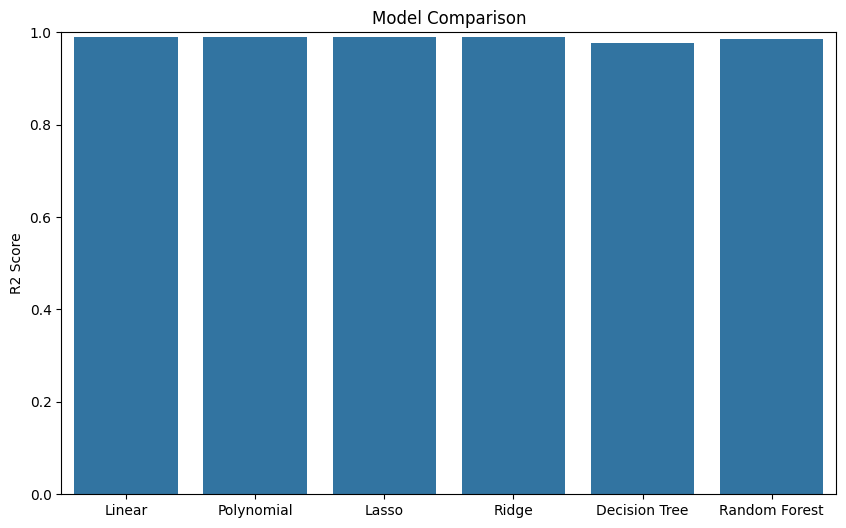

In [66]:
# COMPARE ALL R2 SCORES
models = ['Linear', 'Polynomial', 'Lasso', 'Ridge', 'Decision Tree', 'Random Forest']
scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, poly_pred),
    r2_score(y_test, lasso_pred),
    r2_score(y_test, ridge_pred),
    r2_score(y_test, tree_pred),
    r2_score(y_test, rf_pred)
]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=scores)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()